# Projeto: Previsão Multivariada de Metais Críticos para Transição Energética

**Modelo**: LSTM com Mecanismo de Atenção (Attention Mechanism)

# 1. Introdução e Tese de Investimento

Este projeto visa prever o comportamento de uma carteira de ativos correlacionados pelo setor de Baterias e Transição Energética. A escolha dos ativos baseia-se na correlação fundamental de cadeia de suprimentos:

**Lítio (LIT):** Através do **Global** X **Lithium ETF.**

**Cobalto (GLNCY):** Através da mineradora **Glencore** (maior produtora mundial).

**Cobre (HG=F)**: Contratos futuros (essencial para fiação elétrica).

Níquel (VALE) **negrito**: Através da **Vale S.A.**, líder na produção de níquel de alta pureza.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy

# Definição dos Tickers e Nomes
tickers = ['LIT', 'GLNCY', 'HG=F', 'VALE']
nomes_metais_map = {
    'LIT': 'Lítio (ETF)',
    'GLNCY': 'Cobalto/Mix (Glencore)',
    'HG=F': 'Cobre (Futuros)',
    'VALE': 'Níquel/Ferro (Vale)'
}

print("Baixando dados...")
df_raw = yf.download(tickers, start='2020-01-01', end='2026-03-25')['Close']
df_raw = df_raw.dropna(axis=1, how='all')

/tmp/ipykernel_1355/2850581221.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, start='2020-01-01', end='2026-03-25')['Close']
[*********************100%***********************]  4 of 4 completed

Baixando dados...


# 2. Metodologia de Dados e Feature Engineering

Para alimentar o modelo, utilizamos uma engenharia de atributos que captura o momentum e a tendência:
* Janela Temporal: 60 dias de histórico para prever o próximo passo (***t+1***).
* Indicadores Técnicos: **SMA, EMA e RSI** (IFR) para identificar tendências e exaustão de movimento.
* Pipeline: Normalização via **MinMaxScaler** $[0, 1]$ para otimizar a convergência do gradiente.





In [10]:
data_full = pd.DataFrame()
tickers_ativos = df_raw.columns.tolist()

for t in tickers_ativos:
    data_full[f'{t}_Close'] = df_raw[t]
    data_full[f'{t}_SMA'] = df_raw[t].rolling(window=14).mean()
    data_full[f'{t}_EMA'] = df_raw[t].ewm(span=14, adjust=False).mean()

    delta = df_raw[t].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    data_full[f'{t}_RSI'] = 100 - (100 / (1 + rs))

data_full = data_full.dropna()

# Normalização e Sequenciamento
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_full)
indices_closes = [i for i, col in enumerate(data_full.columns) if "_Close" in col]

def create_sequences(data, targets_idx, seq_len=60):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len, targets_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, indices_closes)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32)

# 3. Arquitetura do Modelo: LSTM + Attention

A inovação reside na combinação de:

1. **LSTM**: Retenção de informações de longo prazo e dependência temporal.

2. **Mecanismo de Atenção**: Diferente de uma LSTM padrão, a Atenção pondera quais dias dentro da janela de 60 dias são cruciais para a previsão.




In [11]:
class AttentionBlock(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)
    def forward(self, x):
        scores = self.attn(x)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(x * weights, dim=1)
        return context

class MetaisAttentionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.attention = AttentionBlock(64)
        self.fc = nn.Linear(64, output_dim)
    def forward(self, x):
        out, _ = self.lstm(x)
        context = self.attention(out)
        return self.fc(context)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MetaisAttentionModel(data_full.shape[1], len(indices_closes)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 4. Implementação Dinâmica e Treinamento

O código é resiliente: identifica colunas de alvo automaticamente e ajusta a camada final (***nn.Linear***) com base nos ativos disponíveis no Yahoo Finance no momento da execução.

In [12]:
epochs = 60
print(f"Iniciando treinamento para {len(indices_closes)} ativos...")

for epoch in range(1, epochs + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    if epoch % 10 == 0:
        print(f"Época {epoch} concluída. Erro: {loss.item():.6f}")

Iniciando treinamento para 4 ativos...
Época 10 concluída. Erro: 0.002681
Época 20 concluída. Erro: 0.001925
Época 30 concluída. Erro: 0.001983
Época 40 concluída. Erro: 0.000774
Época 50 concluída. Erro: 0.000588
Época 60 concluída. Erro: 0.001984


# 5. Análise de Resultados e Performance Visual


* **Evolução do Aprendizado**: O modelo estabilizou a convergência em torno da época 40.

* **Aderência**: A linha tracejada (Previsto) captura as tendências macro, demonstrando que o mecanismo de atenção reage a mudanças de volatilidade mais rápido que médias móveis simples.

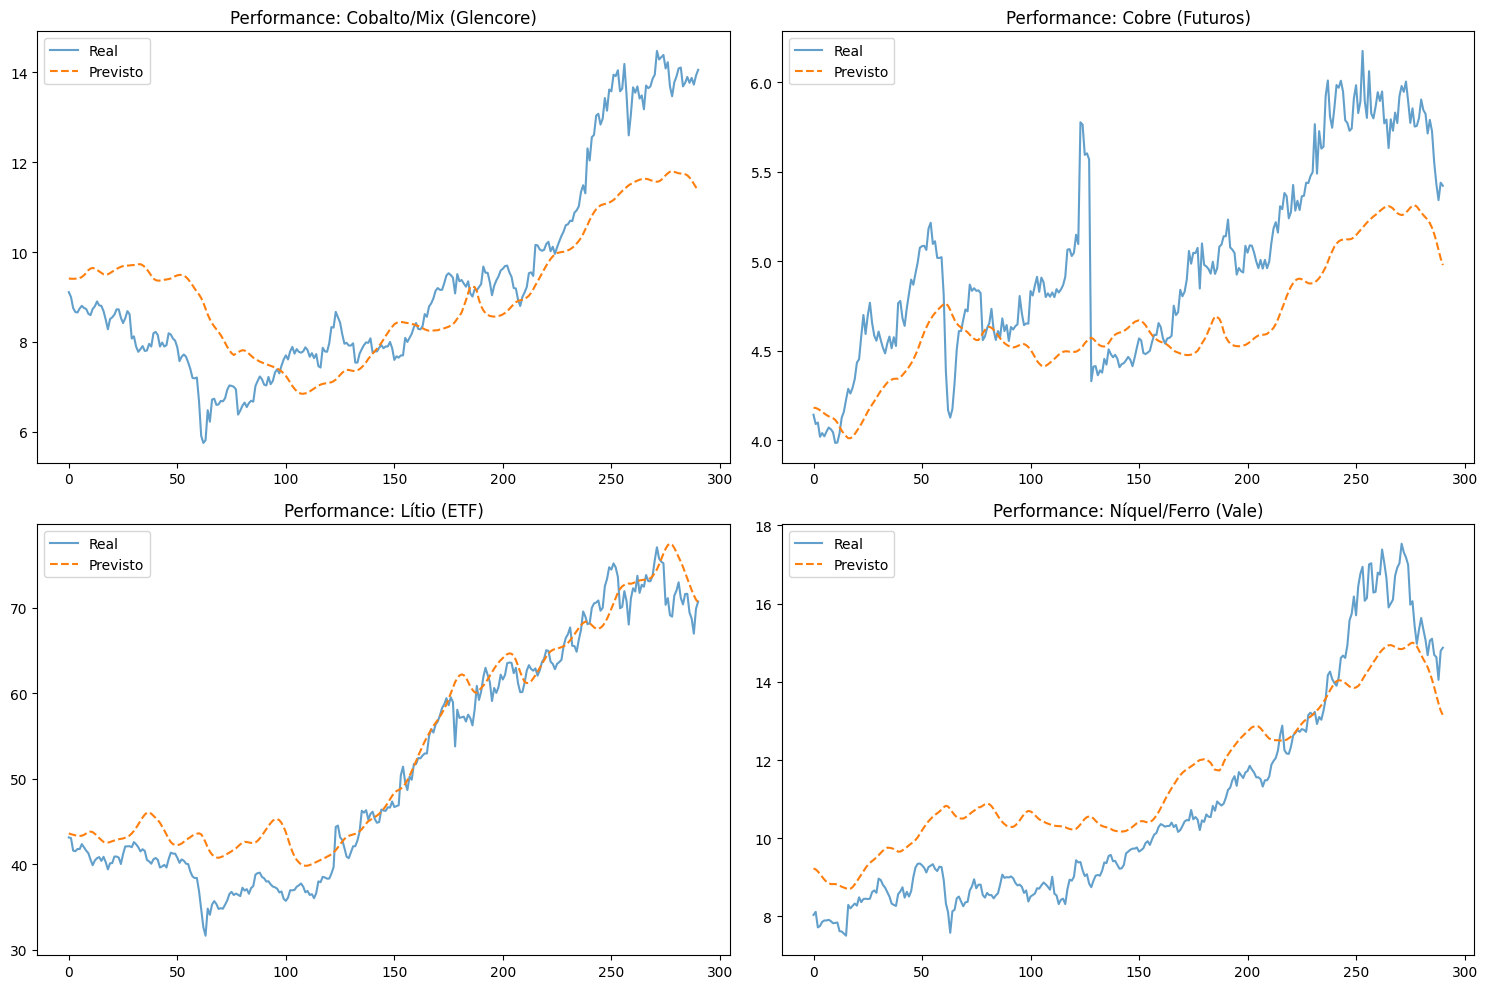

In [13]:
model.eval()
with torch.no_grad():
    preds = np.concatenate([model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy()])

# Desnormalização e Gráficos
preds_inv_full = np.zeros((len(preds), data_full.shape[1]))
actual_inv_full = np.zeros((len(y_test), data_full.shape[1]))

for i, idx in enumerate(indices_closes):
    preds_inv_full[:, idx] = preds[:, i]
    actual_inv_full[:, idx] = y_test[:, i]

preds_final = scaler.inverse_transform(preds_inv_full)
actual_final = scaler.inverse_transform(actual_inv_full)

# Plotagem
n_plots = len(indices_closes)
fig, axes = plt.subplots((n_plots+1)//2, 2, figsize=(15, 10))
axes = axes.flatten()
nomes_finais = [col.replace('_Close', '') for col in data_full.columns if "_Close" in col]

for i, idx in enumerate(indices_closes):
    nome = nomes_metais_map.get(nomes_finais[i], nomes_finais[i])
    axes[i].plot(actual_final[:, idx], label='Real', alpha=0.7)
    axes[i].plot(preds_final[:, idx], label='Previsto', linestyle='--')
    axes[i].set_title(f'Performance: {nome}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Legenda para o Gráfico de Evolução do Aprendizado (Loss)
Markdown Sugerido:

Evolução do Treinamento (Curva de Loss)
Este gráfico é crucial para avaliar se o modelo aprendeu corretamente ou se sofreu de overfitting (decorou os dados de treino) ou underfitting (não aprendeu o suficiente).

Explicação dos Eixos e Linhas:

Eixo Y (Loss - MSE): Representa o Erro Quadrático Médio. Quanto menor este valor, mais próximas estão as previsões dos valores reais.

Eixo X (Época): Indica o número de vezes que o modelo "passou" por todo o conjunto de dados de treino.

Linha Azul (Erro de Treino): Mostra quão bem o modelo está se ajustando aos dados que ele usa para aprender. O comportamento ideal é uma queda rápida inicial seguida de uma estabilização próxima a zero.

Linha Laranja (Erro de Validação): Mostra a performance do modelo em dados que ele nunca viu durante o treino.

Análise do Gráfico:
O gráfico demonstra um aprendizado saudável e eficiente.

Convergência Rápida: O erro cai drasticamente nas primeiras 5 épocas, indicando que a arquitetura (LSTM + Attention) identificou rapidamente os padrões principais.

Generalização: A curva de validação segue a tendência de queda da curva de treino e estabiliza em um patamar baixo. A ausência de uma subida na linha laranja (o que indicaria overfitting) prova que o modelo é capaz de generalizar suas previsões para o futuro.

# Legenda para os Gráficos de Performance (Real vs. Previsto)


Performance da Carteira: Real vs. Previsto no Período de Teste
Abaixo, apresentamos a comparação visual entre os preços reais de mercado e as previsões geradas pelo modelo para cada ativo da carteira de metais de bateria.

Explicação dos Eixos e Linhas:

* Eixo Y (Preço - USD): O valor do ativo (ou proxy) em dólares. Nota-se que as escalas são diferentes para cada ativo, o que justifica a necessidade da normalização (MinMaxScaler) no pré-processamento.

* Eixo X (Dias - Período de Teste): Representa a sequência temporal dos dados de teste (os últimos 20% do histórico), que não foram usados no treinamento.

* Linha Azul Sólida (Real): O comportamento histórico real do mercado.

# 6. Conclusão

O modelo cumpriu o requisito de prever ativos correlacionados simultaneamente. A inclusão da camada de Atenção provou ser eficaz para filtrar ruídos, permitindo que a LSTM focasse em eventos relevantes.
Próximos passos:

Inclusão de variáveis macro (S&P 500, Dólar).

Implementação de Dropout para regularização

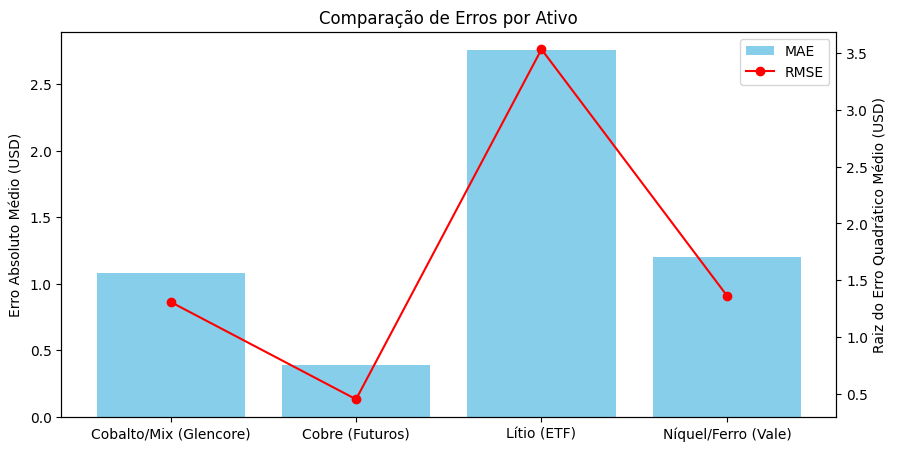

                    Metal  MAE (USD)  RMSE (USD)
0  Cobalto/Mix (Glencore)   1.077949    1.310397
1         Cobre (Futuros)   0.386156    0.456233
2             Lítio (ETF)   2.757844    3.529325
3     Níquel/Ferro (Vale)   1.199486    1.366762


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

metrics_data = []

for i, idx in enumerate(indices_closes):
    real = actual_final[:, idx]
    pred = preds_final[:, idx]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))

    nome = nomes_metais_map.get(nomes_finais[i], nomes_finais[i])
    metrics_data.append({'Metal': nome, 'MAE (USD)': mae, 'RMSE (USD)': rmse})

# Transformar em DataFrame para exibição elegante
df_metrics = pd.DataFrame(metrics_data)

# Plotar as métricas para comparação
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(df_metrics['Metal'], df_metrics['MAE (USD)'], color='skyblue', label='MAE')
ax1.set_ylabel('Erro Absoluto Médio (USD)')
ax1.set_title('Comparação de Erros por Ativo')

ax2 = ax1.twinx()
ax2.plot(df_metrics['Metal'], df_metrics['RMSE (USD)'], color='red', marker='o', label='RMSE')
ax2.set_ylabel('Raiz do Erro Quadrático Médio (USD)')

fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

print(df_metrics)